Extracting data/UCI HAR Dataset.zip...
Extraction complete.
Loading datasets...
Training Optimized SVM (this may take a minute)...
Model Accuracy: 0.9654

Initializing SHAP KernelExplainer...
Calculating SHAP values for test samples...


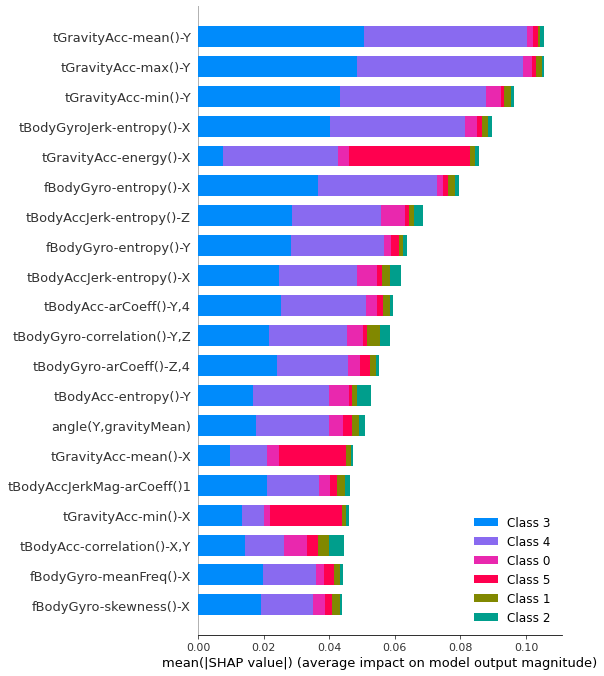


Generating LIME explanation for the first instance...


In [5]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import shap
from lime import lime_tabular

# --- 1. Extraction from your specific path ---
zip_path = 'data/UCI HAR Dataset.zip' # Path
extract_to = 'data/' 

if os.path.exists(zip_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")
else:
    print(f"Error: File not found at {zip_path}. Please check the folder structure.")

# Path where files are extracted
base_path = os.path.join(extract_to, 'UCI HAR Dataset')

# --- 2. Data Loading ---
def load_data(folder, filename):
    return pd.read_csv(os.path.join(base_path, folder, filename), sep=r'\s+', header=None)

print("Loading datasets...")
X_train = load_data('train', 'X_train.txt')
y_train = load_data('train', 'y_train.txt').values.ravel()
X_test = load_data('test', 'X_test.txt')
y_test = load_data('test', 'y_test.txt').values.ravel()

# Load features for naming
features = pd.read_csv(os.path.join(base_path, 'features.txt'), sep=r'\s+', header=None)[1].tolist()
activity_labels = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

X_test_named = pd.DataFrame(X_test.values, columns=features)

# --- 3. SVM Model Training ---
print("Training Optimized SVM (this may take a minute)...")
svm_model = SVC(C=100, kernel='rbf', gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# --- 4. XAI: SHAP Analysis ---
print("\nInitializing SHAP KernelExplainer...")
# Using a small sample for the background to speed up local execution
explainer_sample = shap.utils.sample(X_train, 50) 
svm_explainer = shap.KernelExplainer(svm_model.predict_proba, explainer_sample)

# Explaining 5 samples from the test set
print("Calculating SHAP values for test samples...")
test_sample_for_shap = X_test_named.iloc[:5]
svm_shap_values = svm_explainer.shap_values(test_sample_for_shap)

# Global Importance Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(svm_shap_values, test_sample_for_shap, plot_type="bar")
plt.show()

# --- 5. XAI: LIME Analysis ---
print("\nGenerating LIME explanation for the first instance...")
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=features,
    class_names=activity_labels,
    mode="classification"
)

# Explain instance at index 0
exp = lime_explainer.explain_instance(X_test.iloc[0].values, svm_model.predict_proba)
exp.show_in_notebook()

Extracting dataset...
Extraction complete.

Training CNN model...
Epoch 1/10
207/207 [==============================] - 4s 19ms/step - loss: 0.3927 - accuracy: 0.8543 - val_loss: 0.1130 - val_accuracy: 0.9674
Epoch 2/10
207/207 [==============================] - 4s 18ms/step - loss: 0.1196 - accuracy: 0.9568 - val_loss: 0.0864 - val_accuracy: 0.9742
Epoch 3/10
207/207 [==============================] - 4s 19ms/step - loss: 0.0779 - accuracy: 0.9746 - val_loss: 0.1112 - val_accuracy: 0.9538
Epoch 4/10
207/207 [==============================] - 4s 18ms/step - loss: 0.0584 - accuracy: 0.9796 - val_loss: 0.0605 - val_accuracy: 0.9742
Epoch 5/10
207/207 [==============================] - 4s 18ms/step - loss: 0.0454 - accuracy: 0.9849 - val_loss: 0.0575 - val_accuracy: 0.9715
Epoch 6/10
207/207 [==============================] - 4s 19ms/step - loss: 0.0443 - accuracy: 0.9835 - val_loss: 0.0637 - val_accuracy: 0.9742
Epoch 7/10
207/207 [==============================] - 4s 18ms/step - loss: 0

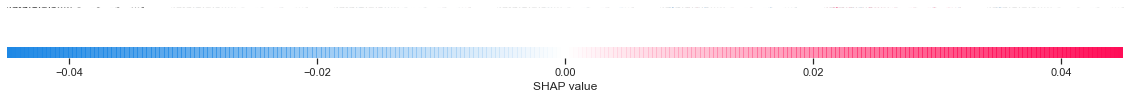

In [7]:
import pandas as pd
import numpy as np
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
import shap

# --- 1. Extraction Logic ---
zip_path = 'data/UCI HAR Dataset.zip'
extract_to = 'data/'

if os.path.exists(zip_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

base_path = os.path.join(extract_to, 'UCI HAR Dataset')

# --- 2. Data Loading & Reshaping for CNN ---
def load_data():
    # Load raw feature vectors
    X_train = pd.read_csv(os.path.join(base_path, "train/X_train.txt"), sep=r'\s+', header=None).values
    y_train = pd.read_csv(os.path.join(base_path, "train/y_train.txt"), header=None).values.ravel() - 1 # 0-indexed
    X_test = pd.read_csv(os.path.join(base_path, "test/X_test.txt"), sep=r'\s+', header=None).values
    y_test = pd.read_csv(os.path.join(base_path, "test/y_test.txt"), header=None).values.ravel() - 1 # 0-indexed

    # CNN 1D expects input shape: (samples, time_steps, features)
    # Since we have 561 features in a row, we treat it as 561 time steps with 1 feature each
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    # One-hot encoding for labels
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)
    
    return X_train, y_train_cat, X_test, y_test_cat, y_test

X_train, y_train_cat, X_test, y_test_cat, y_test = load_data()

# --- 3. Building the 1D-CNN Model ---
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(6, activation='softmax') # 6 Activity Classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nTraining CNN model...")
history  = model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# --- 4. Evaluation ---
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nCNN Test Accuracy: {accuracy*100:.2f}%")

# --- 5. XAI: SHAP for Deep Learning (DeepExplainer) ---
print("\nInitializing SHAP DeepExplainer (this may take time)...")

# Select a small background for SHAP
background = X_train[np.random.choice(X_train.shape[0], 50, replace=False)]
explainer = shap.DeepExplainer(model, background)

# Explain first 5 test samples
test_samples = X_test[:5]
shap_values = explainer.shap_values(test_samples)

# Visualizing results
# Note: Since input is reshaped, we visualize the importance of the 561 feature indices
print("\nGenerating SHAP Plot...")
shap.image_plot(shap_values, -test_samples)

In [4]:
pip install "protobuf<3.20" --force-reinstall

   ---------------------------------------- 896.1/896.1 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.40.1 requires protobuf<6,>=3.20, but you have protobuf 3.19.6 which is incompatible.
tensorflow 2.3.0 requires gast==0.3.3, but you have gast 0.4.0 which is incompatible.
tensorflow 2.3.0 requires numpy<1.19.0,>=1.16.0, but you have numpy 1.23.5 which is incompatible.
tensorflow 2.3.0 requires opt-einsum>=2.3.2, but you have opt-einsum 0+untagged.61.gd905544.dirty which is incompatible.
tensorflow 2.3.0 requires scipy==1.4.1, but you have scipy 1.5.2 which is incompatible.
tensorflow 2.3.0 requires tensorflow-estimator<2.4.0,>=2.3.0, but you have tensorflow-estimator 2.4.0 which is incompatible.


Generating Confusion Matrix...


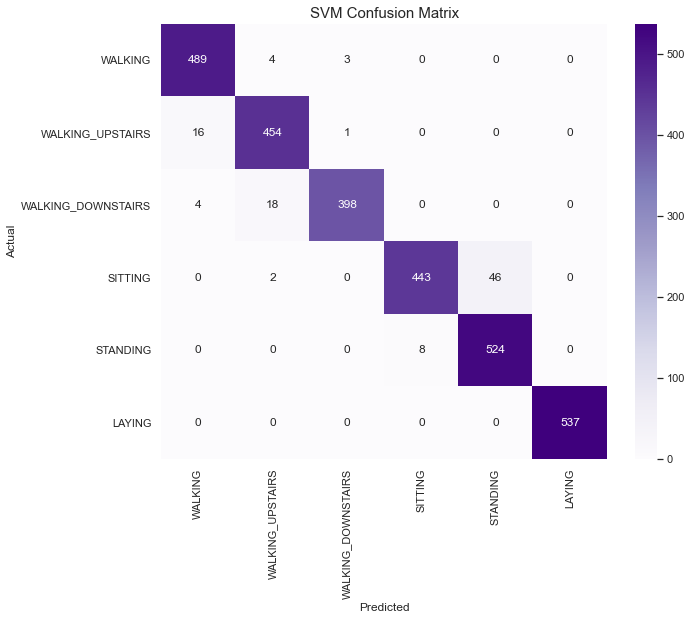

Generating SHAP Bar Plot...


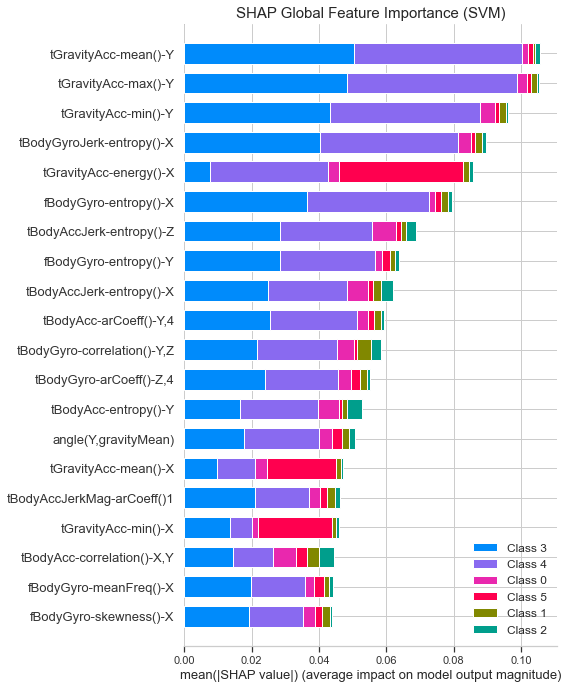

Generating SHAP Beeswarm Plot for Class:  WALKING


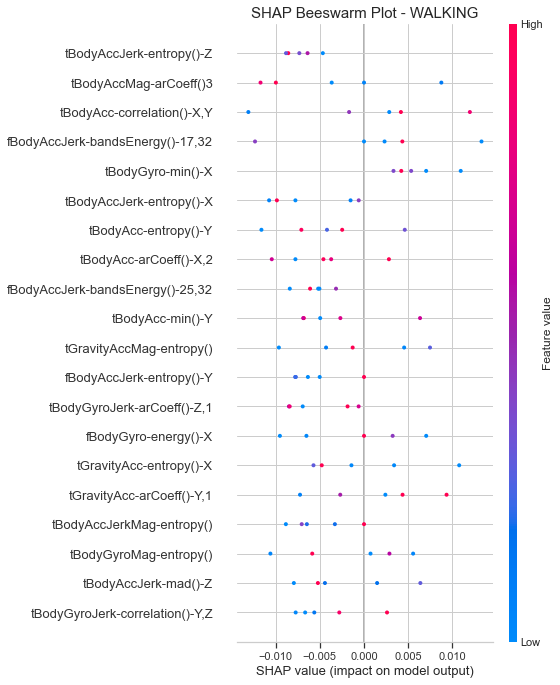

Generating LIME Figure...


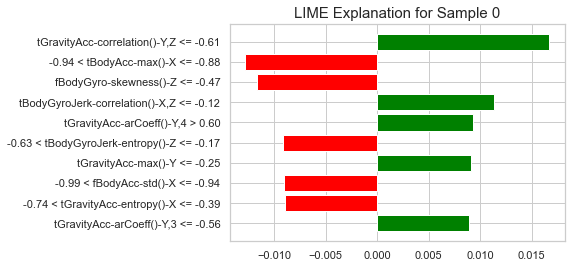


Success! All 4 figures have been saved in your project folder.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Set plotting style
sns.set(style="whitegrid")

# 1. --- Save Confusion Matrix ---
print("Generating Confusion Matrix...")
plt.figure(figsize=(10, 8))
y_pred = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", 
            xticklabels=activity_labels, yticklabels=activity_labels)
plt.title("SVM Confusion Matrix", fontsize=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. --- Save SHAP Global Bar Plot ---
print("Generating SHAP Bar Plot...")
plt.figure(figsize=(12, 8))
# We use show=False to allow saving the plot
shap.summary_plot(svm_shap_values, test_sample_for_shap, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (SVM)", fontsize=15)
plt.savefig('svm_shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. --- Save SHAP Beeswarm Plot ---
# Note: For multiclass, we plot for a specific class (e.g., Index 0: WALKING)
print("Generating SHAP Beeswarm Plot for Class: ", activity_labels[0])
plt.figure(figsize=(12, 8))
shap.summary_plot(svm_shap_values[0], test_sample_for_shap, show=False)
plt.title(f"SHAP Beeswarm Plot - {activity_labels[0]}", fontsize=15)
plt.savefig('svm_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. --- Save LIME Explanation Plot ---
print("Generating LIME Figure...")
# Assuming 'exp' was created in the previous cell
# If not, use: exp = lime_explainer.explain_instance(X_test.iloc[0].values, svm_model.predict_proba)
fig = exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Sample 0", fontsize=15)
plt.savefig('svm_lime_explanation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! All 4 figures have been saved in your project folder.")

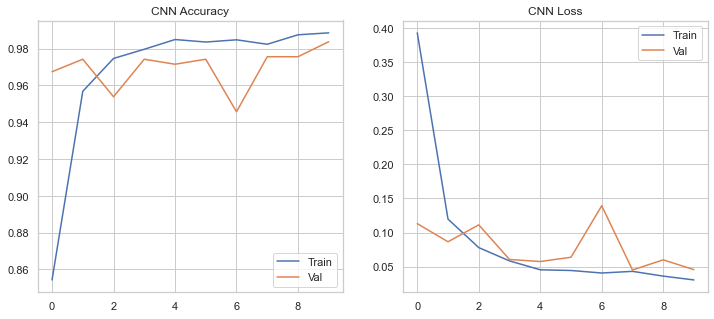

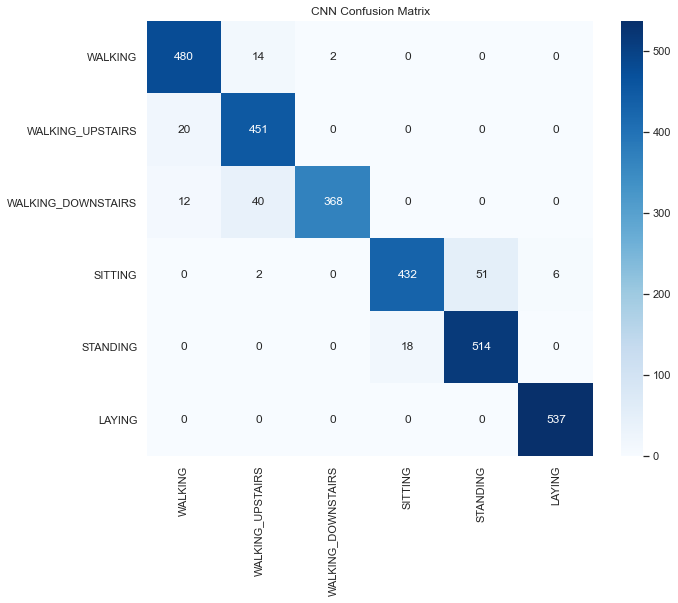

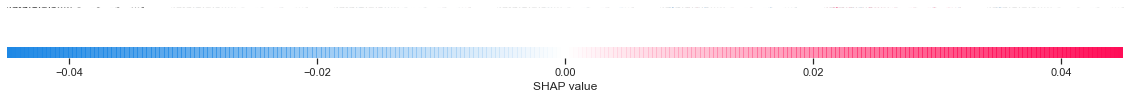

In [8]:
from sklearn.metrics import confusion_matrix

# 1. Save Training Progress (Accuracy & Loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('CNN Loss')
plt.legend()

plt.savefig('cnn_performance.png', dpi=300)
plt.show()

# 2. Save Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=activity_labels, yticklabels=activity_labels)
plt.title("CNN Confusion Matrix")
plt.savefig('cnn_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Save SHAP Plot
shap.image_plot(shap_values, -test_samples, show=False)
plt.savefig('cnn_shap.png', dpi=300, bbox_inches='tight')
plt.show()